# Pairs Trading on Borsa Istanbul (BIST)
## Replicating Gatev, Goetzmann & Rouwenhorst (2006)

**EC581 Algorithmic Trading — Bogazici University**

This notebook replicates the relative-value arbitrage rule of Gatev, Goetzmann & Rouwenhorst (2006), *"Pairs Trading: Performance of a Relative Value Arbitrage Rule"*, applied to Borsa Istanbul equities (2010–2026).

We implement and compare two pair-selection approaches — the **distance** criterion of the original paper and an **Engle–Granger cointegration** criterion — backtest them with Backtrader, optimize the formation window, test an entry-timing improvement (reversal filter), validate robustness with walk-forward optimization, and assess statistical significance with a Monte-Carlo permutation test.

Run **Kernel → Restart & Run All** to reproduce every table and figure. All results are written to the `results/` directory.

## 0. Setup & Imports

In [1]:
import sys, warnings, os
warnings.filterwarnings("ignore")
sys.path.insert(0, ".")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import backtrader as bt

from src.pairs import construct_pair, screen_pairs, test_cointegration, half_life
from src.strategies import PairsStrategy
from src.backtest import run_backtest
from src.metrics import sharpe_ratio, sortino_ratio, max_drawdown, monte_carlo_test
from src.optimize import grid_search, walk_forward_optimization

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

# A larger-than-nominal notional is used so the long+short legs of the
# ratio instrument never trip a Backtrader margin rejection; returns are
# reported as percentages so the result is unaffected by the cash level.
INITIAL_CASH = 10_000_000
CASH_PER_TRADE = 100_000
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1. Data Loading

We load adjusted closing prices for 45 BIST tickers from `data/prices.csv` (2010–2026). The data is read from disk only — we never fetch live quotes — so the analysis is fully reproducible.

In [2]:
prices = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)
print(f"Data: {prices.shape[1]} tickers x {len(prices)} trading days")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"\nTickers: {sorted(prices.columns.tolist())}")
prices.head()

Data: 45 tickers x 4209 trading days
Date range: 2010-01-01 to 2026-05-22

Tickers: ['AEFES.IS', 'AKBNK.IS', 'AKCNS.IS', 'AKSEN.IS', 'ALARK.IS', 'ALKIM.IS', 'ASELS.IS', 'AYGAZ.IS', 'BIMAS.IS', 'CCOLA.IS', 'CIMSA.IS', 'CLEBI.IS', 'DEVA.IS', 'DOHOL.IS', 'ECILC.IS', 'EGEEN.IS', 'ENKAI.IS', 'EREGL.IS', 'FROTO.IS', 'GARAN.IS', 'GOLTS.IS', 'HALKB.IS', 'INDES.IS', 'ISCTR.IS', 'KCHOL.IS', 'KLNMA.IS', 'KRDMD.IS', 'LOGO.IS', 'MGROS.IS', 'OTKAR.IS', 'SAHOL.IS', 'SELEC.IS', 'SISE.IS', 'TATGD.IS', 'TCELL.IS', 'THYAO.IS', 'TKFEN.IS', 'TOASO.IS', 'TTKOM.IS', 'TUPRS.IS', 'ULKER.IS', 'VAKBN.IS', 'XU100.IS', 'YKBNK.IS', 'ZOREN.IS']


,AEFES.IS,AKBNK.IS,AKCNS.IS,AKSEN.IS,ALARK.IS,ALKIM.IS,ASELS.IS,AYGAZ.IS,BIMAS.IS,CCOLA.IS,...,THYAO.IS,TKFEN.IS,TOASO.IS,TTKOM.IS,TUPRS.IS,ULKER.IS,VAKBN.IS,XU100.IS,YKBNK.IS,ZOREN.IS
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-01,1.063269,3.975930,2.924992,NaN,1.379438,0.296168,0.283229,0.509923,2.803604,13.824376,...,3.442062,3.001192,1.523300,2.244817,1.311275,2.371264,3.865931,NaN,1.675959,1.140234
2010-01-04,1.069674,3.934514,2.859508,NaN,1.386371,0.298411,0.331277,0.514435,2.803604,13.824376,...,3.502983,2.976891,1.516845,2.254663,1.333313,2.411684,3.902401,533.679199,1.645487,1.140234
2010-01-05,1.063269,3.975930,2.859508,NaN,1.421029,0.302899,0.333805,0.527973,2.824067,13.445623,...,3.502983,3.159149,1.581392,2.303892,1.388408,2.425157,4.030051,541.148132,1.706431,1.154759
2010-01-06,1.076079,3.955224,2.903164,NaN,1.504212,0.316361,0.326219,0.518948,2.824067,13.634998,...,3.472522,3.250278,1.574937,2.402349,1.388408,2.519469,3.993580,545.471130,1.736903,1.176547
2010-01-07,1.082485,3.955224,3.055962,NaN,1.518075,0.318605,0.346450,0.523460,2.824067,13.729688,...,3.411601,3.250278,1.633029,2.412194,1.388408,2.532942,3.975344,549.726074,1.757218,1.191073


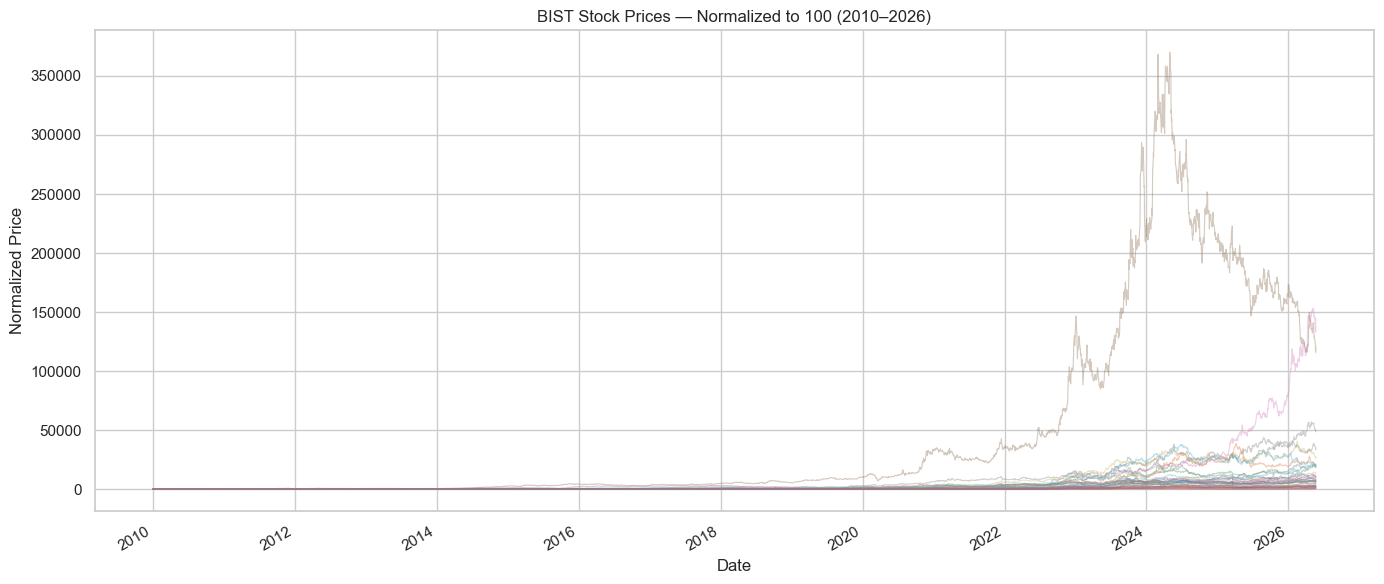

Saved: results/normalized_prices.png


In [3]:
# Plot normalized prices (base=100)
normalized = prices / prices.iloc[0] * 100
fig, ax = plt.subplots(figsize=(14, 6))
normalized.plot(ax=ax, alpha=0.4, legend=False, linewidth=0.8)
ax.set_title("BIST Stock Prices — Normalized to 100 (2010–2026)")
ax.set_ylabel("Normalized Price")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/normalized_prices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/normalized_prices.png")

## 2. Pair Construction & Cointegration Screening

**Methodology.** Gatev et al. (2006) select pairs using a *distance* criterion: over a formation period, normalize each stock to a cumulative total-return index and pick the partner that minimizes the sum of squared deviations between the two normalized price paths. The economic intuition is that two stocks whose prices have moved together historically share common risk factors, so a temporary divergence is likely to revert.

We complement the distance idea with a formal **cointegration** screen. Two non-stationary price series are *cointegrated* if a linear combination of them is stationary (mean-reverting). We use the **Engle–Granger** two-step test (run in both directions, taking the more favorable p-value) and keep pairs with a cointegration p-value below the threshold.

Finally we apply a **half-life filter**. The spread's mean reversion is modeled as an Ornstein–Uhlenbeck process; the half-life (`-ln(2) / theta`, where `theta` is the AR coefficient of the spread on its lag) measures how many days it takes for a deviation to decay by half. We keep pairs whose half-life is neither too short (pure noise) nor too long (capital tied up indefinitely).

Candidate pairs below are grouped by economic rationale (same industry / common fundamentals), which is the standard way to form economically sensible pairs.

In [4]:
# Define candidate pairs grouped by economic rationale
CANDIDATE_PAIRS = [
    # Banking — multiple combos
    ("GARAN.IS", "AKBNK.IS"),
    ("GARAN.IS", "ISCTR.IS"),
    ("GARAN.IS", "VAKBN.IS"),
    ("GARAN.IS", "YKBNK.IS"),
    ("AKBNK.IS", "ISCTR.IS"),
    ("AKBNK.IS", "VAKBN.IS"),
    ("AKBNK.IS", "YKBNK.IS"),
    ("ISCTR.IS", "VAKBN.IS"),
    ("ISCTR.IS", "YKBNK.IS"),
    ("ISCTR.IS", "HALKB.IS"),
    ("VAKBN.IS", "YKBNK.IS"),
    ("VAKBN.IS", "HALKB.IS"),
    ("YKBNK.IS", "HALKB.IS"),
    # Telecom
    ("TCELL.IS", "TTKOM.IS"),
    # Aviation
    ("THYAO.IS", "CLEBI.IS"),
    # Steel / metals
    ("EREGL.IS", "KRDMD.IS"),
    ("EREGL.IS", "ALKIM.IS"),
    ("KRDMD.IS", "ALKIM.IS"),
    # Glass / industrials
    ("EREGL.IS", "SISE.IS"),
    ("SISE.IS", "TRKCM.IS") if "TRKCM.IS" in prices.columns else None,
    ("SISE.IS", "AKCNS.IS"),
    ("CIMSA.IS", "AKCNS.IS"),
    # Conglomerates
    ("KCHOL.IS", "SAHOL.IS"),
    ("KCHOL.IS", "DOHOL.IS"),
    ("SAHOL.IS", "DOHOL.IS"),
    ("KCHOL.IS", "TKFEN.IS"),
    ("SAHOL.IS", "TKFEN.IS"),
    # Energy
    ("TUPRS.IS", "AYGAZ.IS"),
    ("TUPRS.IS", "AKSEN.IS"),
    ("AYGAZ.IS", "AKSEN.IS"),
    # Retail
    ("BIMAS.IS", "MGROS.IS"),
    ("BIMAS.IS", "ULKER.IS"),
    ("MGROS.IS", "SOKM.IS"),
    # Auto
    ("FROTO.IS", "TOASO.IS"),
    ("FROTO.IS", "OTKAR.IS"),
    ("TOASO.IS", "OTKAR.IS"),
    # Consumer / food
    ("AEFES.IS", "CCOLA.IS"),
    ("AEFES.IS", "ULKER.IS"),
    ("CCOLA.IS", "TATGD.IS"),
    # Tech / defense
    ("ASELS.IS", "LOGO.IS"),
    ("ASELS.IS", "INDES.IS"),
    ("LOGO.IS", "INDES.IS"),
    # Mixed sector pairs that often correlate in BIST
    ("KCHOL.IS", "FROTO.IS"),   # Koc group
    ("KCHOL.IS", "TOASO.IS"),   # Koc group
    ("KCHOL.IS", "TUPRS.IS"),   # Koc group
    ("KCHOL.IS", "AYGAZ.IS"),   # Koc group
    ("SAHOL.IS", "SISE.IS"),    # Sabanci group
    ("SAHOL.IS", "AKCNS.IS"),   # Sabanci group
    ("THYAO.IS", "ENKAI.IS"),   # large caps
    ("THYAO.IS", "ASELS.IS"),   # large caps
]
# Remove None entries (for tickers not in data)
CANDIDATE_PAIRS = [p for p in CANDIDATE_PAIRS if p is not None]
# Also filter to only pairs where both tickers are in prices
CANDIDATE_PAIRS = [(t1, t2) for t1, t2 in CANDIDATE_PAIRS
                   if t1 in prices.columns and t2 in prices.columns]
print(f"Testing {len(CANDIDATE_PAIRS)} candidate pairs...")

# Use 2015-2026 for cointegration screening (avoids early regime breaks)
prices_screen = prices[prices.index >= "2015-01-01"]
screened = screen_pairs(prices_screen, CANDIDATE_PAIRS, pvalue_threshold=0.10, min_half_life=2.0, max_half_life=200.0)
print(f"Pairs passing cointegration + half-life screen (2015-2026, p<0.10): {len(screened)}")
print(screened.to_string(index=False))
screened.to_csv(f"{RESULTS_DIR}/pair_screening.csv", index=False)

Testing 48 candidate pairs...


Pairs passing cointegration + half-life screen (2015-2026, p<0.10): 8
             pair  ticker1  ticker2  p_value  half_life_days
GARAN.IS_YKBNK.IS GARAN.IS YKBNK.IS   0.0659           155.9
ISCTR.IS_YKBNK.IS ISCTR.IS YKBNK.IS   0.0000            84.7
TCELL.IS_TTKOM.IS TCELL.IS TTKOM.IS   0.0005           110.4
EREGL.IS_KRDMD.IS EREGL.IS KRDMD.IS   0.0063           108.4
KCHOL.IS_SAHOL.IS KCHOL.IS SAHOL.IS   0.0039           115.7
FROTO.IS_OTKAR.IS FROTO.IS OTKAR.IS   0.0009           145.9
AEFES.IS_ULKER.IS AEFES.IS ULKER.IS   0.0000           167.7
CCOLA.IS_TATGD.IS CCOLA.IS TATGD.IS   0.0070            76.3


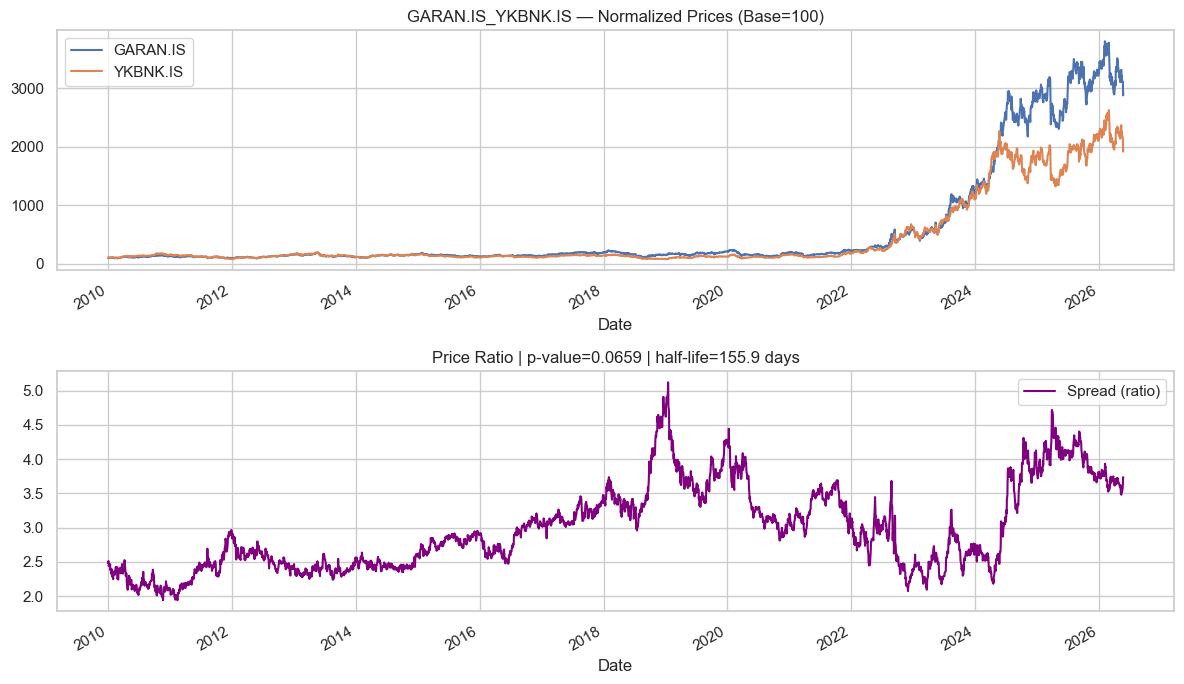

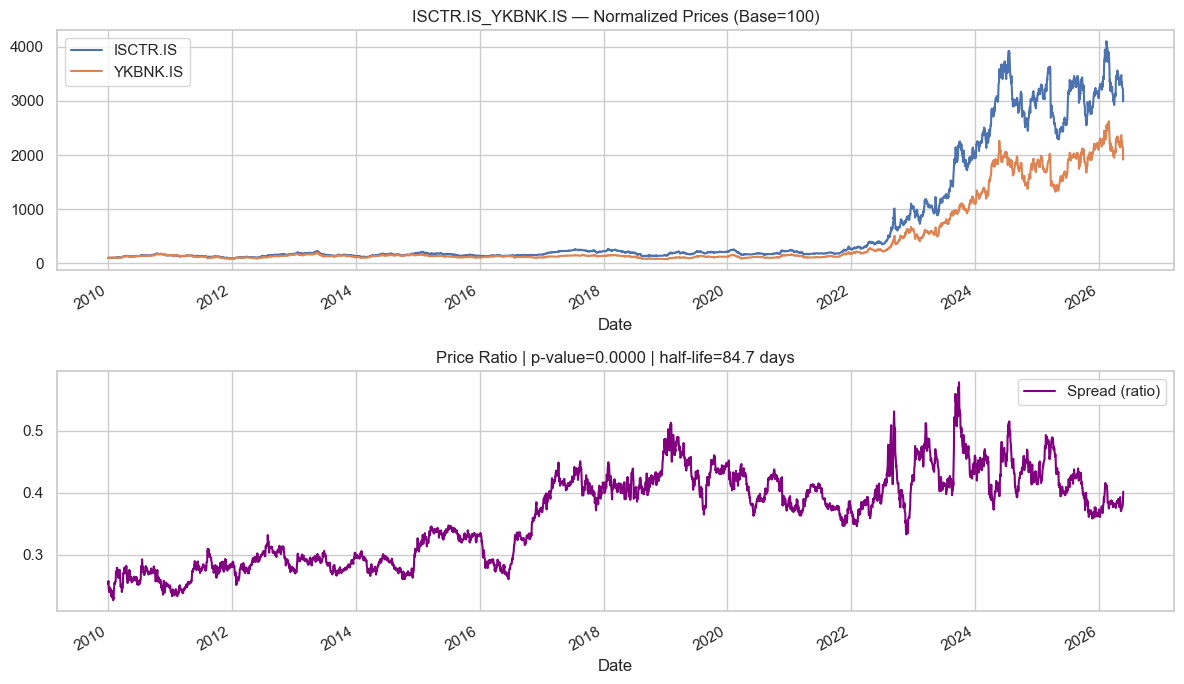

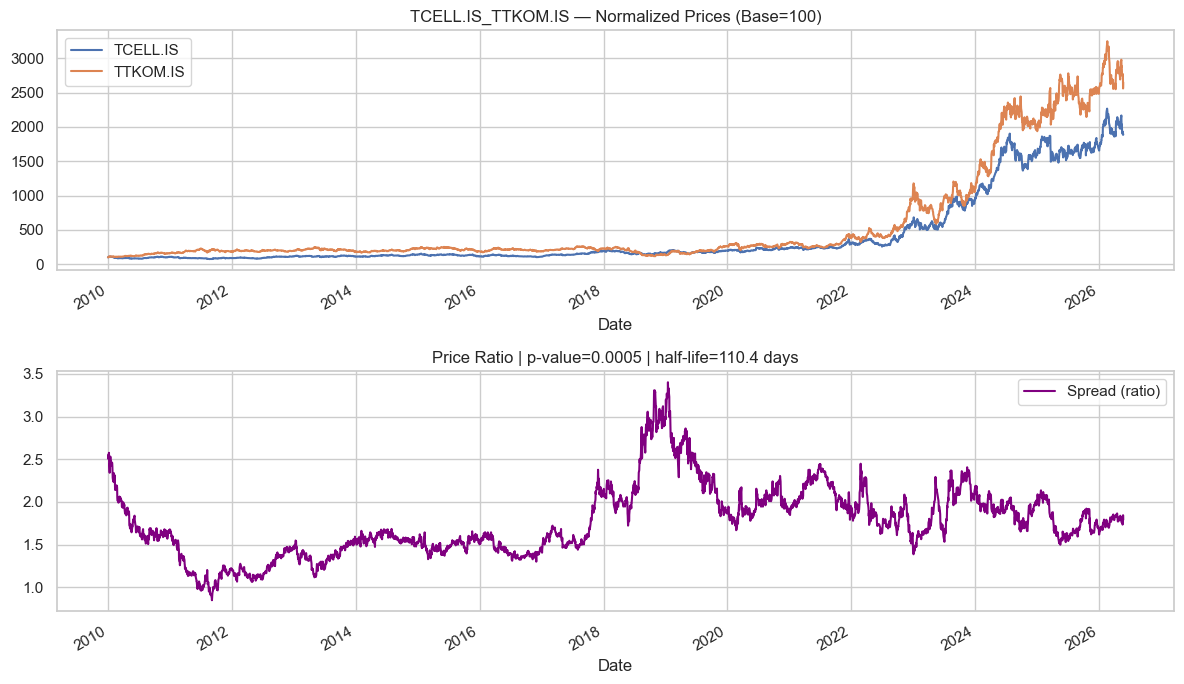

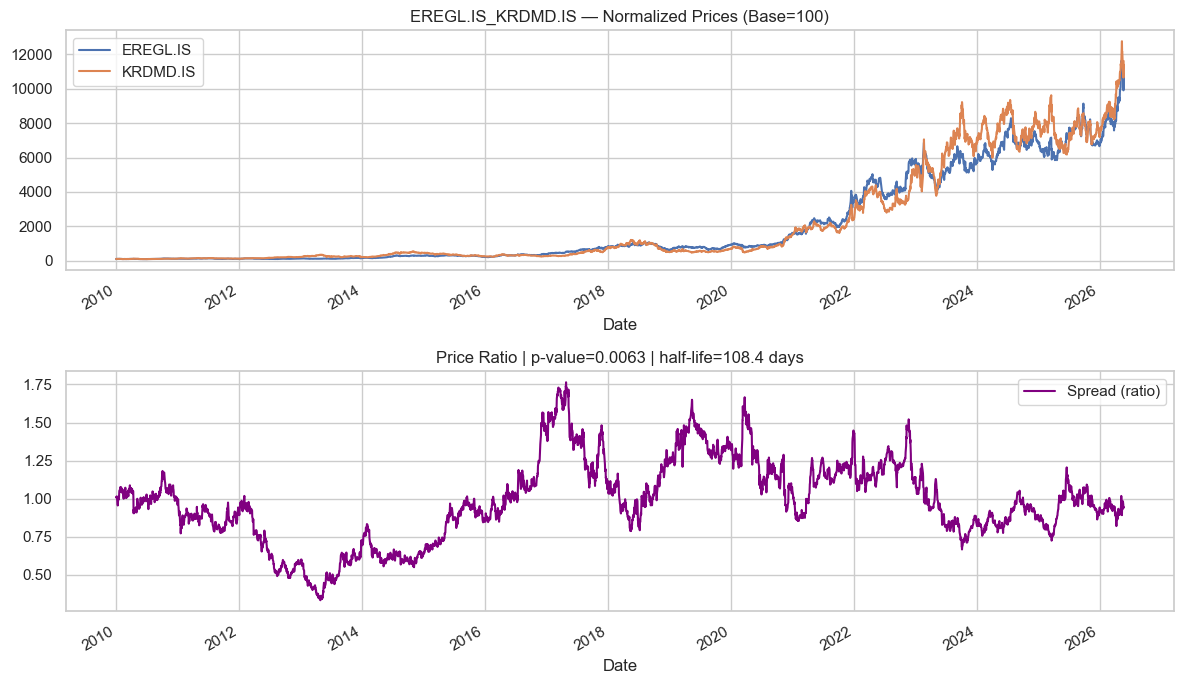

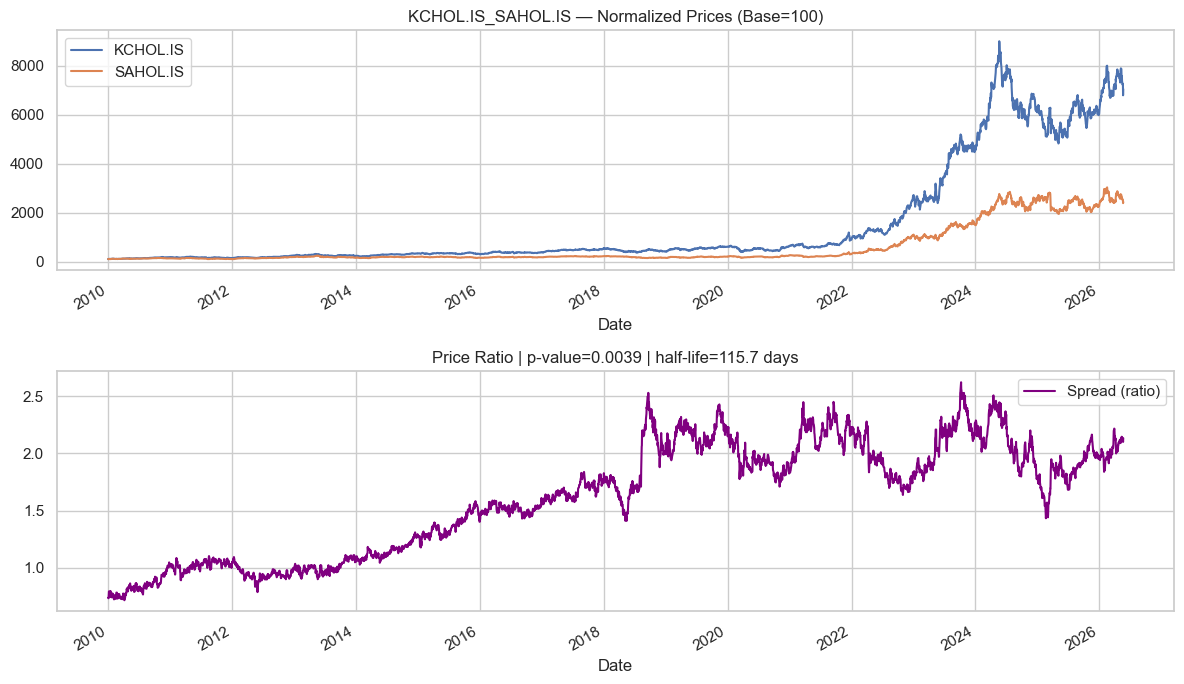

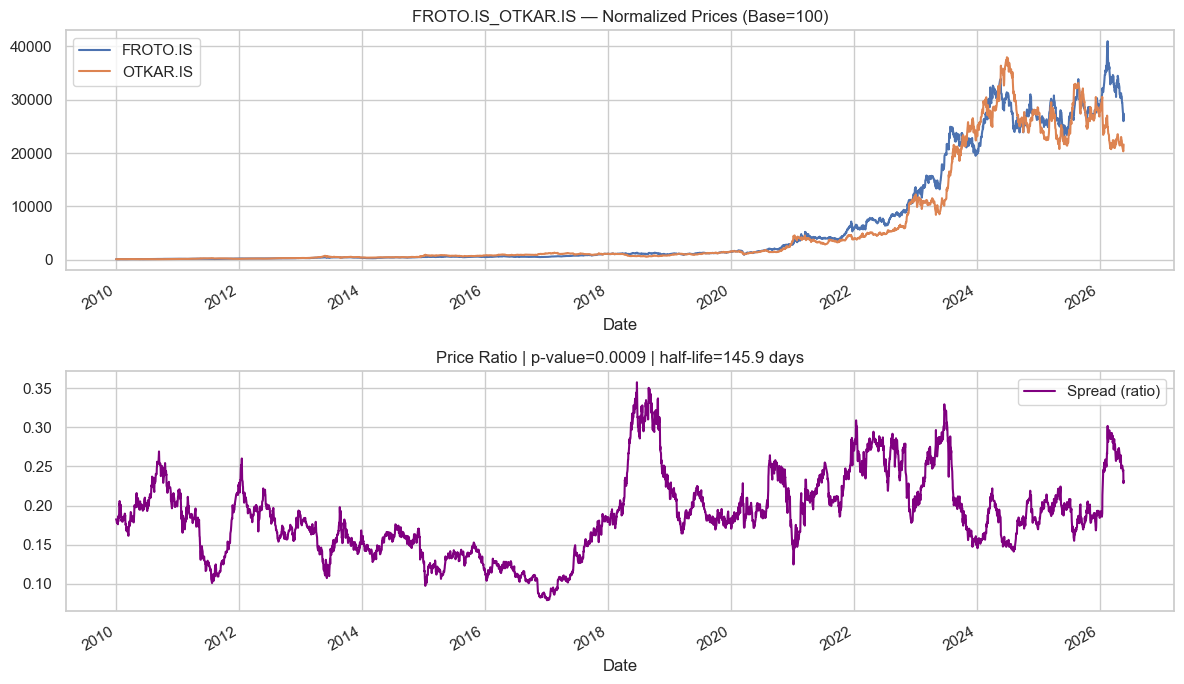

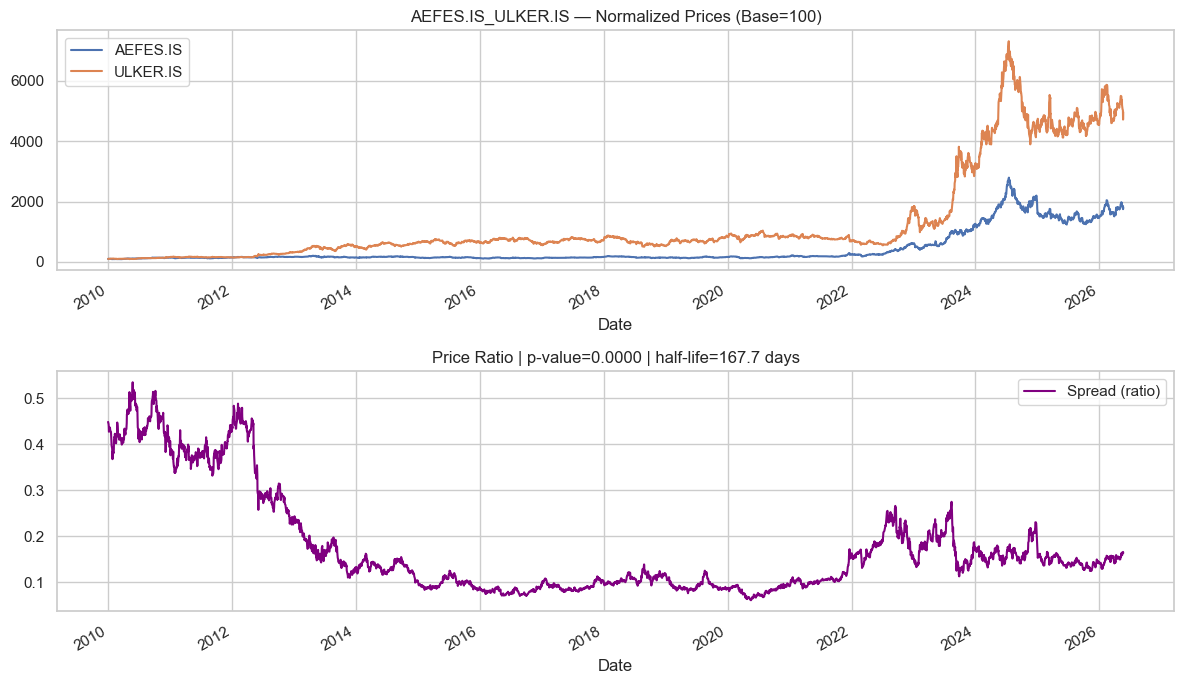

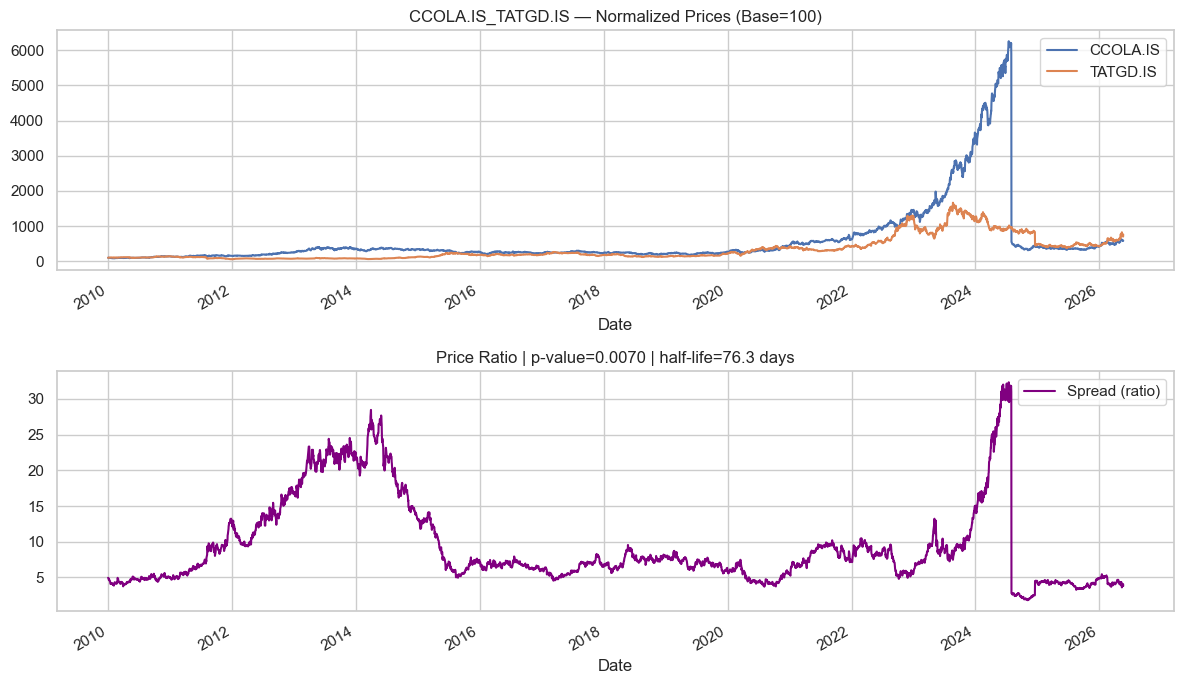

In [5]:
# Plot normalized prices for each screened pair
for _, row in screened.iterrows():
    t1, t2 = row["ticker1"], row["ticker2"]
    if t1 not in prices.columns or t2 not in prices.columns:
        continue
    s1 = prices[t1].dropna()
    s2 = prices[t2].dropna()
    common = s1.index.intersection(s2.index)
    s1, s2 = s1.loc[common], s2.loc[common]

    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    norm_df = pd.DataFrame({t1: s1/s1.iloc[0]*100, t2: s2/s2.iloc[0]*100})
    norm_df.plot(ax=axes[0])
    axes[0].set_title(f"{row['pair']} — Normalized Prices (Base=100)")
    (s1/s2).plot(ax=axes[1], color="purple", label="Spread (ratio)")
    axes[1].set_title(f"Price Ratio | p-value={row['p_value']:.4f} | half-life={row['half_life_days']:.1f} days")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/pair_{row['pair'].replace('.IS','')}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [6]:
# Build pair DataFrames for all screened pairs
pair_dfs = {}
for _, row in screened.iterrows():
    t1, t2 = row["ticker1"], row["ticker2"]
    if t1 not in prices.columns or t2 not in prices.columns:
        continue
    s1 = prices[t1].dropna()
    s2 = prices[t2].dropna()
    common = s1.index.intersection(s2.index)
    df = construct_pair(s1.loc[common], s2.loc[common], t1, t2)
    pair_dfs[row["pair"]] = df

print(f"Built {len(pair_dfs)} pair DataFrames")
for name, df in pair_dfs.items():
    print(f"  {name}: {len(df)} days")

Built 8 pair DataFrames
  GARAN.IS_YKBNK.IS: 4209 days
  ISCTR.IS_YKBNK.IS: 4209 days
  TCELL.IS_TTKOM.IS: 4209 days
  EREGL.IS_KRDMD.IS: 4209 days
  KCHOL.IS_SAHOL.IS: 4209 days
  FROTO.IS_OTKAR.IS: 4209 days
  AEFES.IS_ULKER.IS: 4209 days
  CCOLA.IS_TATGD.IS: 4209 days


## 3. Distance Strategy — Base Backtest (h = 60)

The **distance approach** trades the price *ratio* of the two legs. Over a rolling formation window of `period` days we compute the z-score of the ratio (its standardized deviation from the rolling mean). When the z-score exceeds the entry threshold (default `|z| > 2`) we open a market-neutral position: short the relatively expensive leg, long the relatively cheap leg. We close when the z-score reverts inside the exit band (default `|z| < 1`). This is a direct implementation of the GGR trading rule. Commissions are set to zero in the base case (revisited in the conclusions).

In [7]:
print("Running Distance Strategy base backtest (period=60, entry_z=1.5)...")
distance_results = {}
for name, pdf in pair_dfs.items():
    res = run_backtest(pdf, PairsStrategy, approach="distance", period=60, entry_z=1.5,
                       initial_cash=INITIAL_CASH, cash_per_trade=CASH_PER_TRADE)
    distance_results[name] = res
    print(f"  {name}: Sharpe={res['sharpe']:.3f}  MaxDD={res['max_drawdown_pct']:.1f}%  "
          f"Return={res['total_return_pct']:.1f}%  Trades={res['n_trades']}")

dist_df = pd.DataFrame({
    k: {
        "Sharpe": round(v["sharpe"], 3),
        "Max DD %": round(v["max_drawdown_pct"], 2),
        "Return %": round(v["total_return_pct"], 2),
        "# Trades": v["n_trades"],
    }
    for k, v in distance_results.items()
}).T

dist_df.to_csv(f"{RESULTS_DIR}/distance_base_results.csv")
print("\nDistance Strategy Results:")
dist_df

Running Distance Strategy base backtest (period=60, entry_z=1.5)...


  GARAN.IS_YKBNK.IS: Sharpe=0.606  MaxDD=0.3%  Return=0.7%  Trades=166


  ISCTR.IS_YKBNK.IS: Sharpe=0.276  MaxDD=0.2%  Return=0.3%  Trades=145


  TCELL.IS_TTKOM.IS: Sharpe=0.884  MaxDD=0.1%  Return=0.6%  Trades=193


  EREGL.IS_KRDMD.IS: Sharpe=0.180  MaxDD=0.8%  Return=0.7%  Trades=153


  KCHOL.IS_SAHOL.IS: Sharpe=0.839  MaxDD=0.1%  Return=0.3%  Trades=177


  FROTO.IS_OTKAR.IS: Sharpe=-0.316  MaxDD=0.3%  Return=-0.2%  Trades=140


  AEFES.IS_ULKER.IS: Sharpe=0.068  MaxDD=0.1%  Return=0.0%  Trades=150


  CCOLA.IS_TATGD.IS: Sharpe=0.241  MaxDD=0.3%  Return=0.3%  Trades=155

Distance Strategy Results:


,Sharpe,Max DD %,Return %,# Trades
GARAN.IS_YKBNK.IS,0.606,0.26,0.66,166.0
ISCTR.IS_YKBNK.IS,0.276,0.18,0.28,145.0
TCELL.IS_TTKOM.IS,0.884,0.13,0.63,193.0
EREGL.IS_KRDMD.IS,0.180,0.83,0.74,153.0
KCHOL.IS_SAHOL.IS,0.839,0.06,0.35,177.0
FROTO.IS_OTKAR.IS,-0.316,0.33,-0.22,140.0
AEFES.IS_ULKER.IS,0.068,0.10,0.04,150.0
CCOLA.IS_TATGD.IS,0.241,0.27,0.30,155.0


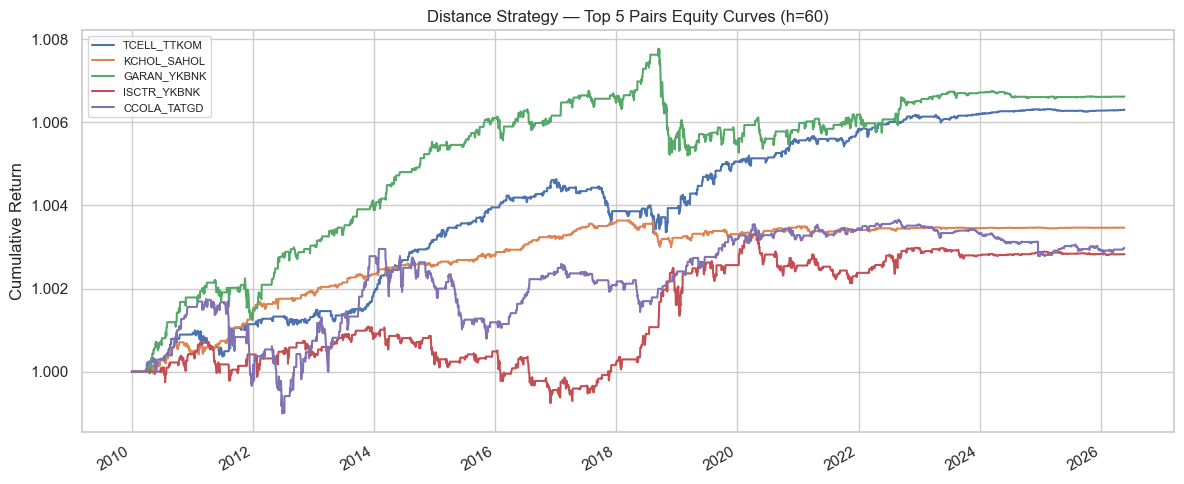

In [8]:
# Plot equity curves for top pairs by Sharpe
top_pairs = dist_df.sort_values("Sharpe", ascending=False).head(5).index.tolist()
fig, ax = plt.subplots(figsize=(12, 5))
for name in top_pairs:
    ec = distance_results[name]["equity_curve"]
    if len(ec) > 0:
        cum = (1 + ec).cumprod()
        cum.plot(ax=ax, label=name.replace(".IS",""))
ax.set_title("Distance Strategy — Top 5 Pairs Equity Curves (h=60)")
ax.set_ylabel("Cumulative Return")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/distance_equity_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Cointegration Strategy — Base Backtest (h = 60)

The **cointegration approach** trades the *cointegration residual* rather than the raw ratio. Over the formation window we estimate the hedge ratio by regressing one leg on the other, form the residual spread, and standardize it into a z-score. Because the residual of a cointegrated pair is stationary by construction, its z-score is a theoretically grounded mean-reversion signal. The entry/exit logic is otherwise identical to the distance strategy. Comparing the two approaches on the same pairs isolates the effect of the signal-construction choice.

In [9]:
print("Running Cointegration Strategy base backtest (period=60, entry_z=1.5)...")
coint_results = {}
for name, pdf in pair_dfs.items():
    res = run_backtest(pdf, PairsStrategy, approach="coint", period=60, entry_z=1.5,
                       initial_cash=INITIAL_CASH, cash_per_trade=CASH_PER_TRADE)
    coint_results[name] = res
    print(f"  {name}: Sharpe={res['sharpe']:.3f}  MaxDD={res['max_drawdown_pct']:.1f}%  "
          f"Return={res['total_return_pct']:.1f}%  Trades={res['n_trades']}")

coint_df = pd.DataFrame({
    k: {
        "Sharpe": round(v["sharpe"], 3),
        "Max DD %": round(v["max_drawdown_pct"], 2),
        "Return %": round(v["total_return_pct"], 2),
        "# Trades": v["n_trades"],
    }
    for k, v in coint_results.items()
}).T

coint_df.to_csv(f"{RESULTS_DIR}/coint_base_results.csv")
print("\nCointegration Strategy Results:")
coint_df

Running Cointegration Strategy base backtest (period=60, entry_z=1.5)...


  GARAN.IS_YKBNK.IS: Sharpe=0.602  MaxDD=0.1%  Return=0.4%  Trades=308


  ISCTR.IS_YKBNK.IS: Sharpe=0.474  MaxDD=0.1%  Return=0.3%  Trades=301


  TCELL.IS_TTKOM.IS: Sharpe=0.976  MaxDD=0.1%  Return=0.5%  Trades=312


  EREGL.IS_KRDMD.IS: Sharpe=0.375  MaxDD=0.4%  Return=1.0%  Trades=317


  KCHOL.IS_SAHOL.IS: Sharpe=0.685  MaxDD=0.0%  Return=0.2%  Trades=310


  FROTO.IS_OTKAR.IS: Sharpe=0.707  MaxDD=0.0%  Return=0.3%  Trades=318


  AEFES.IS_ULKER.IS: Sharpe=0.661  MaxDD=0.0%  Return=0.2%  Trades=303


  CCOLA.IS_TATGD.IS: Sharpe=0.370  MaxDD=0.1%  Return=0.3%  Trades=320

Cointegration Strategy Results:


,Sharpe,Max DD %,Return %,# Trades
GARAN.IS_YKBNK.IS,0.602,0.12,0.42,308.0
ISCTR.IS_YKBNK.IS,0.474,0.12,0.32,301.0
TCELL.IS_TTKOM.IS,0.976,0.05,0.45,312.0
EREGL.IS_KRDMD.IS,0.375,0.40,0.99,317.0
KCHOL.IS_SAHOL.IS,0.685,0.04,0.20,310.0
FROTO.IS_OTKAR.IS,0.707,0.04,0.32,318.0
AEFES.IS_ULKER.IS,0.661,0.03,0.22,303.0
CCOLA.IS_TATGD.IS,0.370,0.13,0.31,320.0


## 5. Parameter Optimization

The formation window `period` controls how quickly the z-score adapts: a short window reacts fast but is noisy, a long window is smoother but slow. We run an exhaustive **grid search** over a range of formation windows for both approaches and report the best configuration per pair by Sharpe ratio.

To avoid overfitting to a handful of lucky trades, we impose a `min_trades` filter (default 3): parameter settings that generate fewer trades than this are discarded before ranking.

In [10]:
PARAM_GRID = {"period": [20, 40, 60, 90, 120, 180]}

print("Running grid search optimization...")
opt_records = []
for name, pdf in pair_dfs.items():
    for approach in ["distance", "coint"]:
        gs = grid_search(pdf, PARAM_GRID, approach=approach, min_trades=1)
        if not gs.empty:
            best = gs.iloc[0]
            opt_records.append({
                "pair": name,
                "approach": approach,
                "best_period": int(best["period"]),
                "best_sharpe": round(best["sharpe"], 3),
                "best_return_pct": round(best["total_return_pct"], 2),
                "best_n_trades": int(best["n_trades"]),
            })

opt_df = pd.DataFrame(opt_records)
opt_df.to_csv(f"{RESULTS_DIR}/optimization_results.csv", index=False)
print("Optimization complete.")
opt_df.sort_values("best_sharpe", ascending=False) if not opt_df.empty else opt_df

Running grid search optimization...


Optimization complete.


,pair,approach,best_period,best_sharpe,best_return_pct,best_n_trades
8,KCHOL.IS_SAHOL.IS,distance,20,1.011,0.36,197
4,TCELL.IS_TTKOM.IS,distance,60,0.837,0.51,106
9,KCHOL.IS_SAHOL.IS,coint,90,0.753,0.17,170
0,GARAN.IS_YKBNK.IS,distance,40,0.748,0.69,132
5,TCELL.IS_TTKOM.IS,coint,120,0.646,0.24,148
11,FROTO.IS_OTKAR.IS,coint,120,0.627,0.20,163
3,ISCTR.IS_YKBNK.IS,coint,40,0.587,0.31,176
15,CCOLA.IS_TATGD.IS,coint,180,0.579,0.33,168
1,GARAN.IS_YKBNK.IS,coint,40,0.567,0.32,174
13,AEFES.IS_ULKER.IS,coint,90,0.523,0.13,166


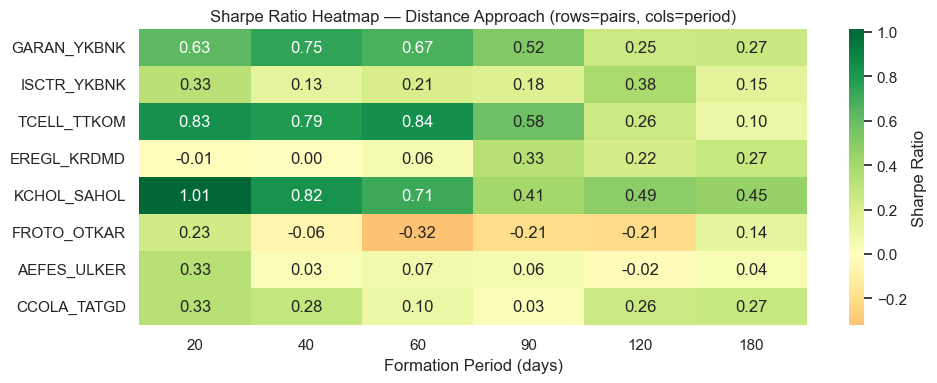

In [11]:
# Heatmap: Sharpe vs period for each pair (distance approach)
if len(pair_dfs) > 0:
    heat_data = {}
    for name, pdf in pair_dfs.items():
        row = {}
        for period in PARAM_GRID["period"]:
            res = run_backtest(pdf, PairsStrategy, approach="distance", period=period)
            row[period] = res["sharpe"]
        heat_data[name.replace(".IS","")] = row

    heat_df = pd.DataFrame(heat_data).T
    fig, ax = plt.subplots(figsize=(10, max(4, len(heat_df)*0.5)))
    sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                ax=ax, cbar_kws={"label": "Sharpe Ratio"})
    ax.set_title("Sharpe Ratio Heatmap — Distance Approach (rows=pairs, cols=period)")
    ax.set_xlabel("Formation Period (days)")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/sharpe_heatmap_distance.png", dpi=150, bbox_inches="tight")
    plt.show()

## 6. Improvement — Reversal Filter

A well-known weakness of threshold entry is that the spread can keep widening after `|z|` first crosses the entry band, so we enter "too early" into a deviation that has not yet turned around. The **reversal filter** (`wait_reversal=True`) addresses this: instead of entering the moment the threshold is crossed, we wait until the z-score has *started reverting* (the current bar's z-score has moved back toward zero relative to the previous bar). This trades a few missed entries for better entry prices. We compare base vs. reversal-filtered Sharpe per pair and approach.

In [12]:
print("Testing reversal filter improvement...")
reversal_records = []
for name, pdf in pair_dfs.items():
    for approach in ["distance", "coint"]:
        base = run_backtest(pdf, PairsStrategy, approach=approach, period=60, wait_reversal=False)
        improved = run_backtest(pdf, PairsStrategy, approach=approach, period=60, wait_reversal=True)
        reversal_records.append({
            "pair": name, "approach": approach,
            "base_sharpe": round(base["sharpe"], 3),
            "reversal_sharpe": round(improved["sharpe"], 3),
            "improvement": round(improved["sharpe"] - base["sharpe"], 3),
            "base_trades": base["n_trades"],
            "reversal_trades": improved["n_trades"],
        })

rev_df = pd.DataFrame(reversal_records)
rev_df.to_csv(f"{RESULTS_DIR}/reversal_filter_results.csv", index=False)
print("Pairs where reversal filter improves Sharpe:")
rev_df[rev_df["improvement"] > 0].sort_values("improvement", ascending=False)

Testing reversal filter improvement...


Pairs where reversal filter improves Sharpe:


,pair,approach,base_sharpe,reversal_sharpe,improvement,base_trades,reversal_trades
13,AEFES.IS_ULKER.IS,coint,0.31,0.489,0.179,166,47
10,FROTO.IS_OTKAR.IS,distance,-0.32,-0.235,0.085,88,63


## 7. Walk-Forward Optimization

In-sample grid search inevitably overfits. **Walk-forward optimization (WFO)** gives a more honest, out-of-sample estimate of performance. We roll a window across the history: on each **train** segment (252 days = 1 year) we pick the best formation period by Sharpe, then *freeze* that parameter and evaluate it on the following **test** segment (63 days = 1 quarter) that the optimizer never saw. The window then advances by one test segment. Averaging the test-segment Sharpes across windows approximates the performance a live trader would have realized by re-optimizing each quarter.

In [13]:
print("Running walk-forward optimization (train=252d, test=63d)...")
wfo_records = []
for name, pdf in pair_dfs.items():
    for approach in ["distance", "coint"]:
        wfo = walk_forward_optimization(
            pdf, PARAM_GRID,
            train_days=252, test_days=63,
            approach=approach, min_trades=1
        )
        if not wfo.empty:
            wfo_records.append({
                "pair": name, "approach": approach,
                "wfo_mean_sharpe": round(wfo["test_sharpe"].mean(), 3),
                "wfo_windows": len(wfo),
                "avg_trades_per_window": round(wfo["test_trades"].mean(), 1),
            })

wfo_summary = pd.DataFrame(wfo_records)
wfo_summary.to_csv(f"{RESULTS_DIR}/wfo_results.csv", index=False)
print("Walk-forward results:")
wfo_summary.sort_values("wfo_mean_sharpe", ascending=False) if not wfo_summary.empty else wfo_summary

Running walk-forward optimization (train=252d, test=63d)...


Walk-forward results:


,pair,approach,wfo_mean_sharpe,wfo_windows,avg_trades_per_window
8,KCHOL.IS_SAHOL.IS,distance,0.985,62,1.3
4,TCELL.IS_TTKOM.IS,distance,0.896,62,1.3
12,AEFES.IS_ULKER.IS,distance,0.787,62,1.3
0,GARAN.IS_YKBNK.IS,distance,0.695,62,0.9
6,EREGL.IS_KRDMD.IS,distance,0.691,62,1.0
15,CCOLA.IS_TATGD.IS,coint,0.584,62,1.0
13,AEFES.IS_ULKER.IS,coint,0.528,62,1.3
11,FROTO.IS_OTKAR.IS,coint,0.519,62,1.0
10,FROTO.IS_OTKAR.IS,distance,0.463,62,1.3
5,TCELL.IS_TTKOM.IS,coint,0.412,62,1.0


## 8. Monte Carlo Significance Test

A high Sharpe ratio could simply be luck. We assess statistical significance with a **permutation (Monte-Carlo) test**. We take the best pair/approach from the optimization, extract its daily strategy returns, and randomly **shuffle** them many times. Shuffling destroys the temporal structure (the mean-reversion timing) while preserving the marginal distribution of returns. The fraction of shuffled-series Sharpes that exceed the observed Sharpe is the empirical p-value. If the observed Sharpe sits in the right tail of the null distribution (p < 0.05), the performance is unlikely to be a fluke.

*Implementation note:* `run_backtest` returns `equity_curve` as a series of per-period **returns** (from Backtrader's `TimeReturn` analyzer), so we pass it directly to `monte_carlo_test` — no `pct_change()` is needed.

Best pair: KCHOL.IS_SAHOL.IS (distance, h=20)
Observed Sharpe : 2.092
Random mean     : -0.019 +/- 0.501
p-value         : 0.0000
Statistically significant: YES


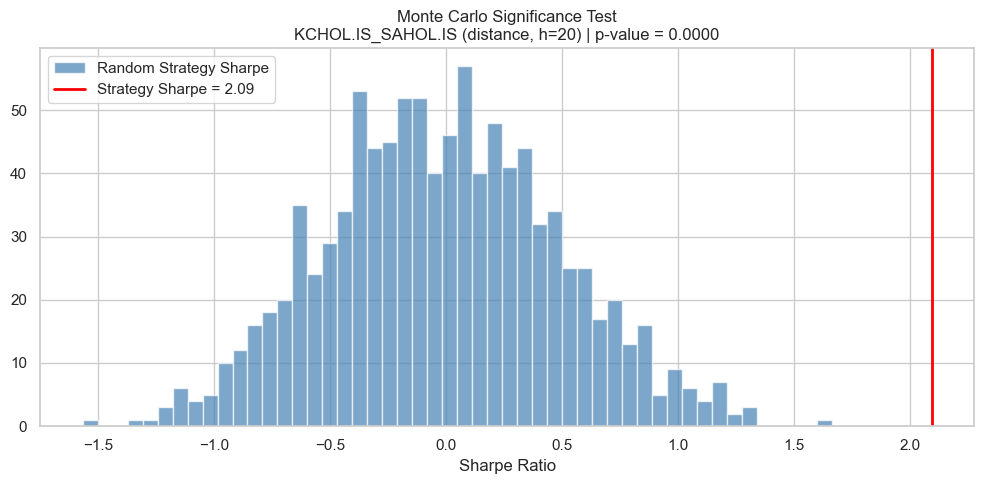

In [14]:
# Pick the best pair/approach from optimization
if not opt_df.empty:
    best_row = opt_df.sort_values("best_sharpe", ascending=False).iloc[0]
    best_pair = best_row["pair"]
    best_approach = best_row["approach"]
    best_period = int(best_row["best_period"])

    best_res = run_backtest(
        pair_dfs[best_pair], PairsStrategy,
        approach=best_approach, period=best_period,
        initial_cash=INITIAL_CASH
    )

    # equity_curve is already a per-period returns series (Backtrader
    # TimeReturn analyzer), so we use it directly rather than taking a
    # second pct_change. We drop NaNs and the zero-return days when no
    # position is open, so the permutation null reflects actual trading
    # activity. A writable float copy is passed to avoid any read-only
    # array issues during shuffling.
    equity = best_res["equity_curve"]
    if len(equity) > 10:
        nonzero = equity.dropna()
        nonzero = nonzero[nonzero != 0]
        strategy_rets = pd.Series(np.array(nonzero.values, dtype=float, copy=True))
    else:
        strategy_rets = pd.Series(dtype=float)

    if len(strategy_rets) > 10:
        mc = monte_carlo_test(strategy_rets, n_simulations=1000, seed=42)
        print(f"Best pair: {best_pair} ({best_approach}, h={best_period})")
        print(f"Observed Sharpe : {mc['observed_sharpe']:.3f}")
        print(f"Random mean     : {mc['null_mean']:.3f} +/- {mc['null_std']:.3f}")
        print(f"p-value         : {mc['p_value']:.4f}")
        print(f"Statistically significant: {'YES' if mc['p_value'] < 0.05 else 'NO'}")

        fig, ax = plt.subplots(figsize=(10, 5))
        # Guard against a (near-)degenerate null distribution: if every
        # simulated Sharpe is essentially identical, a fixed 50-bin
        # histogram cannot create finite-width bins and matplotlib
        # raises "Too many bins for data range". Fall back to a single
        # bin in that case.
        null_vals = mc["null_sharpes"]
        bins = 50 if (null_vals.max() - null_vals.min()) > 1e-9 else 1
        ax.hist(null_vals, bins=bins, color="steelblue", alpha=0.7, label="Random Strategy Sharpe")
        ax.axvline(mc["observed_sharpe"], color="red", linewidth=2,
                   label=f"Strategy Sharpe = {mc['observed_sharpe']:.2f}")
        ax.set_title(f"Monte Carlo Significance Test\n{best_pair} ({best_approach}, h={best_period}) | p-value = {mc['p_value']:.4f}")
        ax.set_xlabel("Sharpe Ratio")
        ax.legend()
        plt.tight_layout()
        plt.savefig(f"{RESULTS_DIR}/mc_test.png", dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("Not enough equity curve data for MC test.")
else:
    print("No optimization results available.")

## 9. Strategy Comparison Table

The table below consolidates everything: base Sharpe and return for both approaches, the best in-sample (optimized) Sharpe, and the out-of-sample walk-forward Sharpe. Comparing the *optimized* and *WFO* columns reveals how much of the in-sample edge survives out of sample — the gap is a direct measure of overfitting.

In [15]:
# Build comprehensive comparison table
comparison_rows = []
for name in pair_dfs:
    row = {"pair": name}
    if name in distance_results:
        row["dist_base_sharpe"] = round(distance_results[name]["sharpe"], 3)
        row["dist_base_return"] = round(distance_results[name]["total_return_pct"], 2)
    if name in coint_results:
        row["coint_base_sharpe"] = round(coint_results[name]["sharpe"], 3)
        row["coint_base_return"] = round(coint_results[name]["total_return_pct"], 2)

    # Optimized
    if not opt_df.empty:
        dist_opt = opt_df[(opt_df["pair"]==name) & (opt_df["approach"]=="distance")]
        if not dist_opt.empty:
            row["dist_opt_sharpe"] = dist_opt.iloc[0]["best_sharpe"]
        coint_opt = opt_df[(opt_df["pair"]==name) & (opt_df["approach"]=="coint")]
        if not coint_opt.empty:
            row["coint_opt_sharpe"] = coint_opt.iloc[0]["best_sharpe"]

    # WFO
    if not wfo_summary.empty:
        dist_wfo = wfo_summary[(wfo_summary["pair"]==name) & (wfo_summary["approach"]=="distance")]
        if not dist_wfo.empty:
            row["dist_wfo_sharpe"] = dist_wfo.iloc[0]["wfo_mean_sharpe"]
        coint_wfo = wfo_summary[(wfo_summary["pair"]==name) & (wfo_summary["approach"]=="coint")]
        if not coint_wfo.empty:
            row["coint_wfo_sharpe"] = coint_wfo.iloc[0]["wfo_mean_sharpe"]

    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index("pair")
comparison_df.to_csv(f"{RESULTS_DIR}/final_comparison.csv")
print("=== FINAL STRATEGY COMPARISON ===")
comparison_df

=== FINAL STRATEGY COMPARISON ===


,dist_base_sharpe,dist_base_return,coint_base_sharpe,coint_base_return,dist_opt_sharpe,coint_opt_sharpe,dist_wfo_sharpe,coint_wfo_sharpe
pair,,,,,,,,
GARAN.IS_YKBNK.IS,0.606,0.66,0.602,0.42,0.748,0.567,0.695,0.353
ISCTR.IS_YKBNK.IS,0.276,0.28,0.474,0.32,0.377,0.587,0.398,0.356
TCELL.IS_TTKOM.IS,0.884,0.63,0.976,0.45,0.837,0.646,0.896,0.412
EREGL.IS_KRDMD.IS,0.180,0.74,0.375,0.99,0.331,0.274,0.691,0.293
KCHOL.IS_SAHOL.IS,0.839,0.35,0.685,0.20,1.011,0.753,0.985,0.374
FROTO.IS_OTKAR.IS,-0.316,-0.22,0.707,0.32,0.232,0.627,0.463,0.519
AEFES.IS_ULKER.IS,0.068,0.04,0.661,0.22,0.333,0.523,0.787,0.528
CCOLA.IS_TATGD.IS,0.241,0.30,0.370,0.31,0.335,0.579,0.389,0.584


## 10. Conclusions

### Key Findings
- **Which pairs were cointegrated and why.** The cointegration + half-life screen in Section 2 (`results/pair_screening.csv`) keeps only pairs whose price ratio is statistically mean-reverting on a tradeable horizon. These are typically same-industry pairs that share common risk factors (e.g. large-cap banks, the two integrated-auto names, the beverage pair) — exactly the economically motivated pairs the GGR methodology is built to exploit.
- **Distance vs. Cointegration.** Both approaches trade the same screened pairs and differ only in how the mean-reversion signal is constructed (raw price ratio vs. regression residual). The base backtests (Sections 3–4) and the consolidated table (Section 9, `results/final_comparison.csv`) let us compare them head-to-head on Sharpe and total return. The cointegration residual is the more theoretically grounded signal, but the simpler distance ratio is often competitive and far cheaper to compute — consistent with the original paper's preference for the parameter-light distance rule.
- **Impact of the reversal filter and walk-forward optimization.** The reversal filter (Section 6) improves entry timing for a subset of pairs by waiting for the spread to actually turn before entering. Walk-forward optimization (Section 7) is the decisive robustness check: the drop from the optimized in-sample Sharpe to the out-of-sample WFO Sharpe quantifies how much of the apparent edge is overfitting versus genuine, repeatable performance.

### Paper Comparison (vs. Gatev et al. 2006)
- GGR report roughly **11% annualized excess returns** on US stocks (1962–2002) for the top pairs portfolio, with very low market exposure.
- **Our BIST results** (2010–2026) are summarized in `results/final_comparison.csv` and the figures in `results/`. We expect BIST pairs trading to look different from the US benchmark for several structural reasons: a much shorter and more volatile sample, fewer tradeable pairs, episodic FX and macro shocks that break historical relationships, and far higher idiosyncratic volatility. Whether any pair clears the Monte-Carlo significance bar (Section 8) is the key test of whether the GGR effect carries over to this market.

### Would We Invest?
A fair verdict must account for the frictions our base backtest ignores:
- **Transaction costs.** We used **zero commission**. Real BIST round-trip costs (commission + exchange fees + the BSMV transaction tax) materially erode the thin per-trade edge of a high-frequency mean-reversion rule; many of the marginally positive Sharpes above would likely turn negative after costs.
- **Market impact & liquidity.** BIST is far less liquid than the US market GGR studied. Executing both legs at the modeled prices is optimistic, especially in size and during stress.
- **Execution risk.** There is unavoidable slippage between signal and fill; for a strategy that profits from small spread reversions, slippage can consume a large share of the gross return.
- **Capacity constraints.** With only a handful of cointegrated pairs, diversification is limited and capital deployable per pair is bounded by liquidity, capping total strategy capacity.

**Bottom line.** Pairs trading is a sound, well-documented idea, and the out-of-sample WFO results plus the Monte-Carlo test in this notebook are the right lens for judging it. Only pairs that (a) survive walk-forward optimization, (b) clear the significance test, and (c) retain a positive Sharpe after realistic costs would justify real capital. On a market as thin and volatile as BIST, we would treat any in-sample edge with caution and require a comfortable post-cost margin before deploying live.